In [ ]:

# STEP 1: LIBRARY IMPORTS + DATASET LOAD
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Load Dataset ──────────────────────────────────────────────
df = pd.read_csv('/content/aids (1).csv')   # <-- Upload your file in Colab first

print("Dataset Loaded Successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Columns:\n{df.columns.tolist()}")
print(f"\n🔍 First 5 rows:")
df.head()

Dataset Loaded Successfully!
📊 Shape: 2759 rows × 23 columns

📋 Columns:
['Country', 'Year', 'Data.AIDS-Related Deaths.AIDS Orphans', 'Data.AIDS-Related Deaths.Adults', 'Data.AIDS-Related Deaths.All Ages', 'Data.AIDS-Related Deaths.Children', 'Data.AIDS-Related Deaths.Female Adults', 'Data.AIDS-Related Deaths.Male Adults', 'Data.HIV Prevalence.Adults', 'Data.HIV Prevalence.Young Men', 'Data.HIV Prevalence.Young Women', 'Data.New HIV Infections.Young Adults', 'Data.New HIV Infections.Male Adults', 'Data.New HIV Infections.Female Adults', 'Data.New HIV Infections.Children', 'Data.New HIV Infections.All Ages', 'Data.New HIV Infections.Adults', 'Data.New HIV Infections.Incidence Rate Among Adults', 'Data.People Living with HIV.Total', 'Data.People Living with HIV.Male Adults', 'Data.People Living with HIV.Female Adults', 'Data.People Living with HIV.Children', 'Data.People Living with HIV.Adults']

🔍 First 5 rows:


,Country,Year,Data.AIDS-Related Deaths.AIDS Orphans,Data.AIDS-Related Deaths.Adults,Data.AIDS-Related Deaths.All Ages,Data.AIDS-Related Deaths.Children,Data.AIDS-Related Deaths.Female Adults,Data.AIDS-Related Deaths.Male Adults,Data.HIV Prevalence.Adults,Data.HIV Prevalence.Young Men,Data.HIV Prevalence.Young Women,Data.New HIV Infections.Young Adults,Data.New HIV Infections.Male Adults,Data.New HIV Infections.Female Adults,Data.New HIV Infections.Children,Data.New HIV Infections.All Ages,Data.New HIV Infections.Adults,Data.New HIV Infections.Incidence Rate Among Adults,Data.People Living with HIV.Total,Data.People Living with HIV.Male Adults,Data.People Living with HIV.Female Adults,Data.People Living with HIV.Children,Data.People Living with HIV.Adults
0,Afghanistan,1990,100,100,100,100,100,100,0.10,0.10,0.10,100,100,100,100,100,100,0.01,500,500,100,100,500
1,Algeria,1990,200,100,100,100,100,100,0.10,0.10,0.10,100,100,100,100,100,100,0.01,500,500,200,100,500
2,Angola,1990,1300,500,1000,500,200,200,0.20,0.10,0.20,2600,1200,1700,1000,3400,2800,0.47,12000,4600,6100,1100,11000
3,Argentina,1990,500,200,500,100,100,200,0.10,0.10,0.10,4100,3100,1200,200,4500,4400,0.19,13000,9100,3700,200,13000
4,Armenia,1990,100,100,100,100,100,100,0.10,0.10,0.10,100,100,100,100,100,100,0.01,100,100,100,100,100


In [ ]:
# ============================================================
# STEP 2: DATA CLEANING + PREPROCESSING + TARGET CREATION
# ============================================================

# ── Step 2.1: Column names short karo ────────────────────────
df.columns = [
    'Country', 'Year', 'AIDS_Orphans', 'Deaths_Adults', 'Deaths_All',
    'Deaths_Children', 'Deaths_Female', 'Deaths_Male',
    'Prevalence_Adults', 'Prevalence_YoungMen', 'Prevalence_YoungWomen',
    'NewInfections_YoungAdults', 'NewInfections_Male', 'NewInfections_Female',
    'NewInfections_Children', 'NewInfections_All', 'NewInfections_Adults',
    'Incidence_Rate', 'PLHIV_Total', 'PLHIV_Male', 'PLHIV_Female',
    'PLHIV_Children', 'PLHIV_Adults'
]

print(" Columns renamed!")

# ── Step 2.2: Missing values check ───────────────────────────
print(f"\n🔍 Missing Values: {df.isnull().sum().sum()} (Total)")

# ── Step 2.3: Duplicates check ───────────────────────────────
print(f"🔍 Duplicate Rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f" After removing duplicates: {df.shape}")

# ── Step 2.4: Data types confirm ─────────────────────────────
print(f"\n📋 Data Types:\n{df.dtypes}")

# ── Step 2.5: TARGET VARIABLE CREATE ─────────────────────────
# Prevalence_Adults ki median se HIGH / LOW risk classify karein ge
median_prev = df['Prevalence_Adults'].median()
print(f"\n📊 Prevalence Adults Median: {median_prev}")

df['Risk_Level'] = (df['Prevalence_Adults'] > median_prev).astype(int)
# 1 = High Risk, 0 = Low Risk

print(f"\n🎯 Target Variable Distribution:")
print(df['Risk_Level'].value_counts())
print(f"\nClass Balance:")
print(df['Risk_Level'].value_counts(normalize=True).round(3) * 100)

# ── Step 2.6: Country Label Encoding ─────────────────────────
le = LabelEncoder()
df['Country_Encoded'] = le.fit_transform(df['Country'])
print(f"\n Country encoded! Unique countries: {df['Country'].nunique()}")

# ── Step 2.7: Final cleaned dataset info ─────────────────────
print(f"\n Final Dataset Shape: {df.shape}")
print(f"\n Sample Data:")
df.head(3)

 Columns renamed!

🔍 Missing Values: 0 (Total)
🔍 Duplicate Rows: 0
 After removing duplicates: (2759, 23)

📋 Data Types:
Country                       object
Year                           int64
AIDS_Orphans                   int64
Deaths_Adults                  int64
Deaths_All                     int64
Deaths_Children                int64
Deaths_Female                  int64
Deaths_Male                    int64
Prevalence_Adults            float64
Prevalence_YoungMen          float64
Prevalence_YoungWomen        float64
NewInfections_YoungAdults      int64
NewInfections_Male             int64
NewInfections_Female           int64
NewInfections_Children         int64
NewInfections_All              int64
NewInfections_Adults           int64
Incidence_Rate               float64
PLHIV_Total                    int64
PLHIV_Male                     int64
PLHIV_Female                   int64
PLHIV_Children                 int64
PLHIV_Adults                   int64
dtype: object

📊 Prevalence 

,Country,Year,AIDS_Orphans,Deaths_Adults,Deaths_All,Deaths_Children,Deaths_Female,Deaths_Male,Prevalence_Adults,Prevalence_YoungMen,Prevalence_YoungWomen,NewInfections_YoungAdults,NewInfections_Male,NewInfections_Female,NewInfections_Children,NewInfections_All,NewInfections_Adults,Incidence_Rate,PLHIV_Total,PLHIV_Male,PLHIV_Female,PLHIV_Children,PLHIV_Adults,Risk_Level,Country_Encoded
0,Afghanistan,1990,100,100,100,100,100,100,0.10,0.10,0.10,100,100,100,100,100,100,0.01,500,500,100,100,500,0,0
1,Algeria,1990,200,100,100,100,100,100,0.10,0.10,0.10,100,100,100,100,100,100,0.01,500,500,200,100,500,0,1
2,Angola,1990,1300,500,1000,500,200,200,0.20,0.10,0.20,2600,1200,1700,1000,3400,2800,0.47,12000,4600,6100,1100,11000,0,2


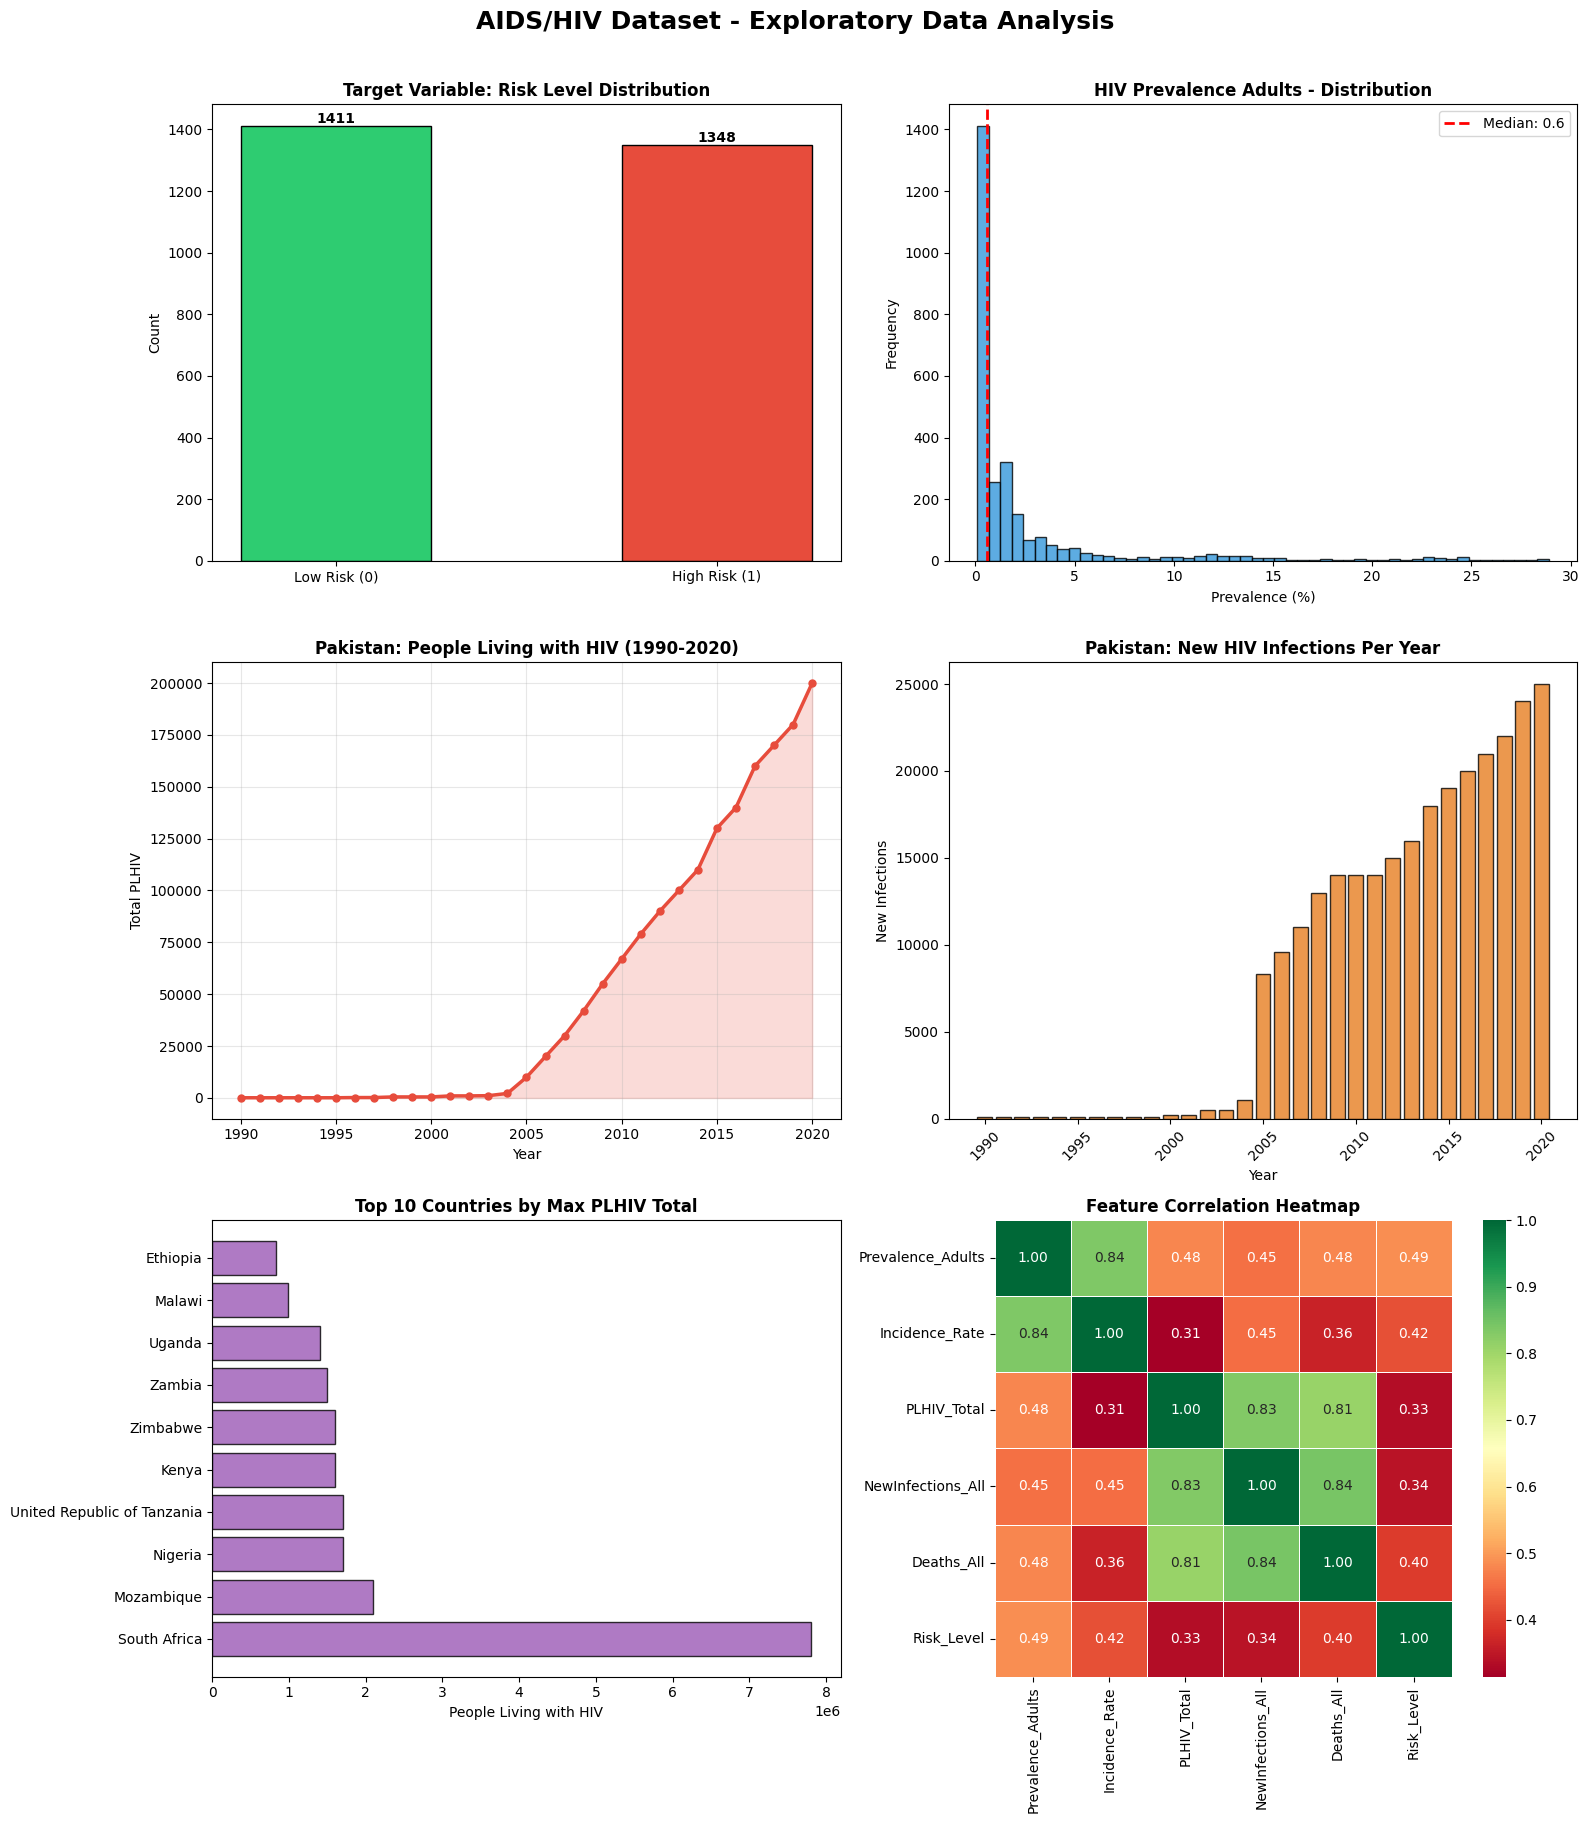

 EDA Complete — 6 Graphs Generated!


In [ ]:
# ============================================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('AIDS/HIV Dataset - Exploratory Data Analysis',
             fontsize=18, fontweight='bold', y=1.01)

# ── Graph 1: Risk Level Distribution ─────────────────────────
axes[0,0].bar(['Low Risk (0)', 'High Risk (1)'],
               df['Risk_Level'].value_counts().values,
               color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0,0].set_title('Target Variable: Risk Level Distribution', fontweight='bold')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(df['Risk_Level'].value_counts().values):
    axes[0,0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# ── Graph 2: HIV Prevalence Distribution ─────────────────────
axes[0,1].hist(df['Prevalence_Adults'], bins=50,
               color='#3498db', edgecolor='black', alpha=0.8)
axes[0,1].set_title('HIV Prevalence Adults - Distribution', fontweight='bold')
axes[0,1].set_xlabel('Prevalence (%)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].axvline(df['Prevalence_Adults'].median(), color='red',
                   linestyle='--', linewidth=2, label=f'Median: {df["Prevalence_Adults"].median()}')
axes[0,1].legend()

# ── Graph 3: Pakistan HIV Trend Over Years ────────────────────
pak = df[df['Country'] == 'Pakistan']
axes[1,0].plot(pak['Year'], pak['PLHIV_Total'],
               color='#e74c3c', linewidth=2.5, marker='o', markersize=5)
axes[1,0].set_title('Pakistan: People Living with HIV (1990-2020)', fontweight='bold')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Total PLHIV')
axes[1,0].fill_between(pak['Year'], pak['PLHIV_Total'], alpha=0.2, color='#e74c3c')
axes[1,0].grid(True, alpha=0.3)

# ── Graph 4: New Infections by Year (Pakistan) ────────────────
axes[1,1].bar(pak['Year'], pak['NewInfections_All'],
              color='#e67e22', edgecolor='black', alpha=0.8)
axes[1,1].set_title('Pakistan: New HIV Infections Per Year', fontweight='bold')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('New Infections')
axes[1,1].tick_params(axis='x', rotation=45)

# ── Graph 5: Top 10 Countries by PLHIV Total ─────────────────
top10 = df.groupby('Country')['PLHIV_Total'].max().nlargest(10)
axes[2,0].barh(top10.index, top10.values,
               color='#9b59b6', edgecolor='black', alpha=0.8)
axes[2,0].set_title('Top 10 Countries by Max PLHIV Total', fontweight='bold')
axes[2,0].set_xlabel('People Living with HIV')

# ── Graph 6: Correlation Heatmap ──────────────────────────────
numeric_cols = ['Prevalence_Adults', 'Incidence_Rate', 'PLHIV_Total',
                'NewInfections_All', 'Deaths_All', 'Risk_Level']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[2,1], linewidths=0.5, square=True)
axes[2,1].set_title('Feature Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()
print(" EDA Complete — 6 Graphs Generated!")

In [ ]:
# ============================================================
# STEP 4: FEATURE ENGINEERING
# ============================================================

# ── Feature 1: Death Rate Ratio ──────────────────────────────
df['Death_Rate_Ratio'] = df['Deaths_All'] / (df['PLHIV_Total'] + 1)

# ── Feature 2: Child Impact Ratio ────────────────────────────
df['Child_Impact_Ratio'] = df['PLHIV_Children'] / (df['PLHIV_Total'] + 1)

# ── Feature 3: Gender Infection Gap ──────────────────────────
df['Gender_Gap'] = df['NewInfections_Male'] - df['NewInfections_Female']

# ── Feature 4: Infection Growth Rate ─────────────────────────
df['Infection_Growth'] = df.groupby('Country')['NewInfections_All'].pct_change().fillna(0)

# ── Feature 5: PLHIV Growth Rate ─────────────────────────────
df['PLHIV_Growth'] = df.groupby('Country')['PLHIV_Total'].pct_change().fillna(0)

# ── Feature 6: Young People Prevalence Gap ───────────────────
df['Young_Prev_Gap'] = df['Prevalence_YoungWomen'] - df['Prevalence_YoungMen']

# ── Feature 7: Orphan Burden ─────────────────────────────────
df['Orphan_Burden'] = df['AIDS_Orphans'] / (df['PLHIV_Total'] + 1)

# ── Feature 8: Treatment Gap Proxy ───────────────────────────
df['Treatment_Gap'] = df['PLHIV_Total'] - df['PLHIV_Adults'] - df['PLHIV_Children']

# ── Infinity / NaN clean up ───────────────────────────────────
df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)

print(" Feature Engineering Complete!")
print(f"📊 New Shape: {df.shape}")
print(f"\n🆕 New Features Added:")
new_features = ['Death_Rate_Ratio', 'Child_Impact_Ratio', 'Gender_Gap',
                'Infection_Growth', 'PLHIV_Growth', 'Young_Prev_Gap',
                'Orphan_Burden', 'Treatment_Gap']
for f in new_features:
    print(f"   ✔ {f} — min: {df[f].min():.3f}, max: {df[f].max():.3f}, mean: {df[f].mean():.3f}")

print(f"\n Final Dataset Shape after Feature Engineering: {df.shape}")

 Feature Engineering Complete!
📊 New Shape: (2759, 33)

🆕 New Features Added:
   ✔ Death_Rate_Ratio — min: 0.005, max: 0.990, mean: 0.080
   ✔ Child_Impact_Ratio — min: 0.002, max: 0.990, mean: 0.105
   ✔ Gender_Gap — min: -100000.000, max: 102000.000, mean: -2099.166
   ✔ Infection_Growth — min: -0.600, max: 6.545, mean: 0.043
   ✔ PLHIV_Growth — min: -0.091, max: 4.000, mean: 0.106
   ✔ Young_Prev_Gap — min: -2.300, max: 17.300, mean: 1.073
   ✔ Orphan_Burden — min: 0.002, max: 1.839, mean: 0.407
   ✔ Treatment_Gap — min: -94000.000, max: 90000.000, mean: -169.880

 Final Dataset Shape after Feature Engineering: (2759, 33)


In [ ]:
# ============================================================
# STEP 5: FEATURE SELECTION + TRAIN/TEST SPLIT + SCALING
# ============================================================

# ── Step 5.1: Feature Selection ──────────────────────────────
feature_cols = [
    'Year', 'Country_Encoded',
    'Prevalence_YoungMen', 'Prevalence_YoungWomen',
    'NewInfections_All', 'NewInfections_Male', 'NewInfections_Female',
    'NewInfections_Children', 'Incidence_Rate',
    'PLHIV_Total', 'PLHIV_Male', 'PLHIV_Female', 'PLHIV_Children',
    'Deaths_All', 'Deaths_Male', 'Deaths_Female', 'Deaths_Children',
    'AIDS_Orphans',
    'Death_Rate_Ratio', 'Child_Impact_Ratio', 'Gender_Gap',
    'Infection_Growth', 'PLHIV_Growth', 'Young_Prev_Gap',
    'Orphan_Burden', 'Treatment_Gap'
]

X = df[feature_cols]
y = df['Risk_Level']

print(f"Features Selected: {X.shape[1]}")
print(f" Target Shape: {y.shape}")
print(f"\n📊 Class Distribution:\n{y.value_counts()}")

# ── Step 5.2: Train/Test Split (80/20) ───────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Train/Test Split Done!")
print(f"   🔹 Training Set : {X_train.shape[0]} rows")
print(f"   🔹 Testing Set  : {X_test.shape[0]} rows")

# ── Step 5.3: Feature Scaling ─────────────────────────

Features Selected: 26
 Target Shape: (2759,)

📊 Class Distribution:
Risk_Level
0    1411
1    1348
Name: count, dtype: int64

 Train/Test Split Done!
   🔹 Training Set : 2207 rows
   🔹 Testing Set  : 552 rows


In [ ]:
# Fresh dataframe reload
df2 = pd.read_csv('/content/aids.csv')
df2.columns = [
    'Country', 'Year', 'AIDS_Orphans', 'Deaths_Adults', 'Deaths_All',
    'Deaths_Children', 'Deaths_Female', 'Deaths_Male',
    'Prevalence_Adults', 'Prevalence_YoungMen', 'Prevalence_YoungWomen',
    'NewInfections_YoungAdults', 'NewInfections_Male', 'NewInfections_Female',
    'NewInfections_Children', 'NewInfections_All', 'NewInfections_Adults',
    'Incidence_Rate', 'PLHIV_Total', 'PLHIV_Male', 'PLHIV_Female',
    'PLHIV_Children', 'PLHIV_Adults'
]
df2.drop_duplicates(inplace=True)

median_inf = df2['NewInfections_All'].median()
df2['High_Spread'] = (df2['NewInfections_All'] > median_inf).astype(int)

print(f" Done! Target Distribution:")
print(df2['High_Spread'].value_counts())

 Done! Target Distribution:
High_Spread
0    1386
1    1373
Name: count, dtype: int64


In [ ]:
# Feature Engineering
le2 = LabelEncoder()
df2['Country_Encoded'] = le2.fit_transform(df2['Country'])

df2['Death_Rate_Ratio']  = df2['Deaths_All'] / (df2['PLHIV_Total'] + 1)
df2['Child_Impact_Ratio']= df2['PLHIV_Children'] / (df2['PLHIV_Total'] + 1)
df2['Gender_Gap']        = df2['NewInfections_Male'] - df2['NewInfections_Female']
df2['Young_Prev_Gap']    = df2['Prevalence_YoungWomen'] - df2['Prevalence_YoungMen']
df2['Orphan_Burden']     = df2['AIDS_Orphans'] / (df2['PLHIV_Total'] + 1)
df2['PLHIV_Growth']      = df2.groupby('Country')['PLHIV_Total'].pct_change().fillna(0)
df2['Deaths_Growth']     = df2.groupby('Country')['Deaths_All'].pct_change().fillna(0)
df2['Male_Female_PLHIV'] = df2['PLHIV_Male'] / (df2['PLHIV_Female'] + 1)

df2.replace([np.inf, -np.inf], 0, inplace=True)
df2.fillna(0, inplace=True)

print(f" Feature Engineering Done!")
print(f"Shape: {df2.shape}")

 Feature Engineering Done!
Shape: (2759, 33)


In [ ]:
# Split + Scale
feature_cols2 = [
    'Year', 'Country_Encoded',
    'Prevalence_Adults', 'Prevalence_YoungMen', 'Prevalence_YoungWomen',
    'Deaths_All', 'Deaths_Male', 'Deaths_Female', 'Deaths_Children',
    'PLHIV_Total', 'PLHIV_Male', 'PLHIV_Female', 'PLHIV_Children',
    'AIDS_Orphans', 'Incidence_Rate',
    'Death_Rate_Ratio', 'Child_Impact_Ratio', 'Gender_Gap',
    'Young_Prev_Gap', 'Orphan_Burden', 'PLHIV_Growth',
    'Deaths_Growth', 'Male_Female_PLHIV'
]

X2 = df2[feature_cols2]
y2 = df2['High_Spread']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

print(f" Split + Scale Done!")
print(f"   Train: {X2_train.shape[0]} rows")
print(f"   Test : {X2_test.shape[0]} rows")
print(f"   Features: {X2.shape[1]}")

 Split + Scale Done!
   Train: 2207 rows
   Test : 552 rows
   Features: 23


In [ ]:
# Random Forest
print(" Training Random Forest...")
rf2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)
rf2.fit(X2_train_sc, y2_train)

rf2_tr = accuracy_score(y2_train, rf2.predict(X2_train_sc))
rf2_te = accuracy_score(y2_test,  rf2.predict(X2_test_sc))

print(f"    RF Train Accuracy : {rf2_tr*100:.2f}%")
print(f"    RF Test  Accuracy : {rf2_te*100:.2f}%")

 Training Random Forest...
    RF Train Accuracy : 99.59%
    RF Test  Accuracy : 98.73%


In [ ]:
# XGBoost
print(" Training XGBoost...")
xgb2 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb2.fit(X2_train_sc, y2_train)

xgb2_tr = accuracy_score(y2_train, xgb2.predict(X2_train_sc))
xgb2_te = accuracy_score(y2_test,  xgb2.predict(X2_test_sc))

print(f"   ✅ XGB Train Accuracy : {xgb2_tr*100:.2f}%")
print(f"   ✅ XGB Test  Accuracy : {xgb2_te*100:.2f}%")

⚡ Training XGBoost...
   ✅ XGB Train Accuracy : 100.00%
   ✅ XGB Test  Accuracy : 98.73%


In [ ]:
# Neural Network (15 Epochs)
print(" Training Neural Network...")
tf.random.set_seed(42)

nn2 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X2_train_sc.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

nn2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = nn2.fit(
    X2_train_sc, y2_train,
    epochs=15,
    batch_size=32,
    validation_data=(X2_test_sc, y2_test),
    verbose=1
)

nn2_tr = history2.history['accuracy'][-1]
nn2_te = history2.history['val_accuracy'][-1]
print(f"\n   ✅ NN Train Accuracy : {nn2_tr*100:.2f}%")
print(f"   ✅ NN Test  Accuracy : {nn2_te*100:.2f}%")

🧠 Training Neural Network...
Epoch 1/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.8627 - loss: 0.3124 - val_accuracy: 0.8786 - val_loss: 0.3882
Epoch 2/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9230 - loss: 0.1883 - val_accuracy: 0.9330 - val_loss: 0.2431
Epoch 3/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9361 - loss: 0.1562 - val_accuracy: 0.9457 - val_loss: 0.1725
Epoch 4/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9429 - loss: 0.1419 - val_accuracy: 0.9620 - val_loss: 0.1256
Epoch 5/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9533 - loss: 0.1201 - val_accuracy: 0.9638 - val_loss: 0.1071
Epoch 6/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9542 - loss: 0.1151 - val_accuracy: 0.9638 - val_loss: 0.1015
Epoch 7/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9615 - loss: 0.1010 - val_accuracy: 0.9620 - val_loss: 0.0890
Epoch 8/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9628 - loss: 0.1008 -

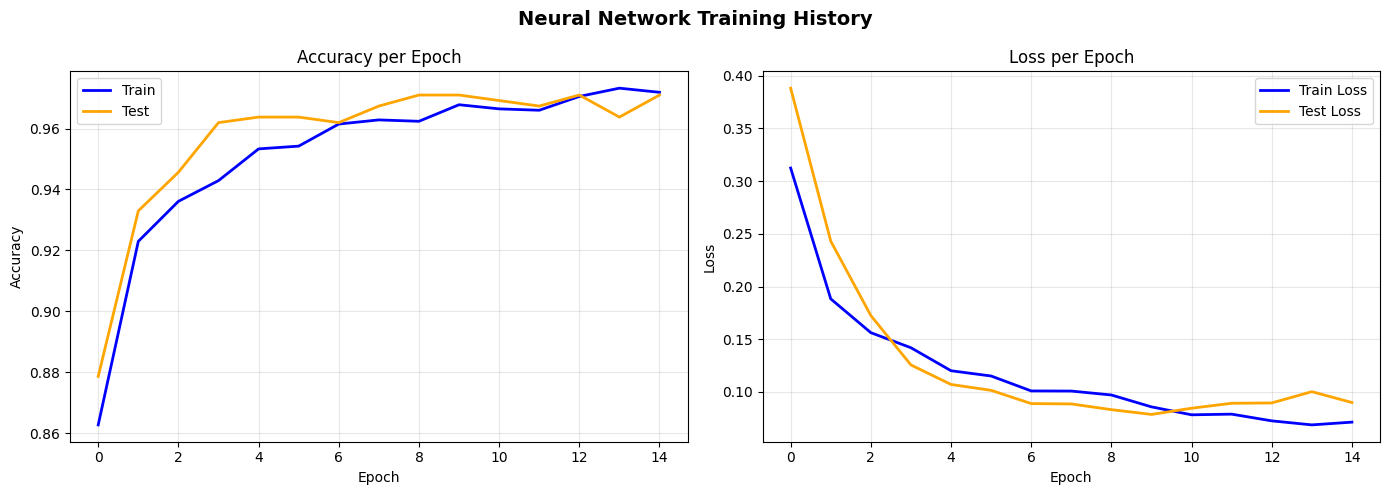

✅ Epoch Plot Done!


In [ ]:
# Epoch History Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Neural Network Training History', fontsize=14, fontweight='bold')

axes[0].plot(history2.history['accuracy'],     label='Train', color='blue',   linewidth=2)
axes[0].plot(history2.history['val_accuracy'], label='Test',  color='orange', linewidth=2)
axes[0].set_title('Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history2.history['loss'],     label='Train Loss', color='blue',   linewidth=2)
axes[1].plot(history2.history['val_loss'], label='Test Loss',  color='orange', linewidth=2)
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(" Epoch Plot Done!")

                MODEL EVALUATION REPORT                

🔹 Random Forest
   Accuracy  : 98.73%
   Precision : 98.91%
   Recall    : 98.55%
   F1 Score  : 98.72%
   ROC-AUC   : 99.93%

🔹 XGBoost
   Accuracy  : 98.73%
   Precision : 98.91%
   Recall    : 98.55%
   F1 Score  : 98.72%
   ROC-AUC   : 99.96%
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

🔹 Neural Network
   Accuracy  : 97.10%
   Precision : 98.50%
   Recall    : 95.64%
   F1 Score  : 97.05%
   ROC-AUC   : 99.67%


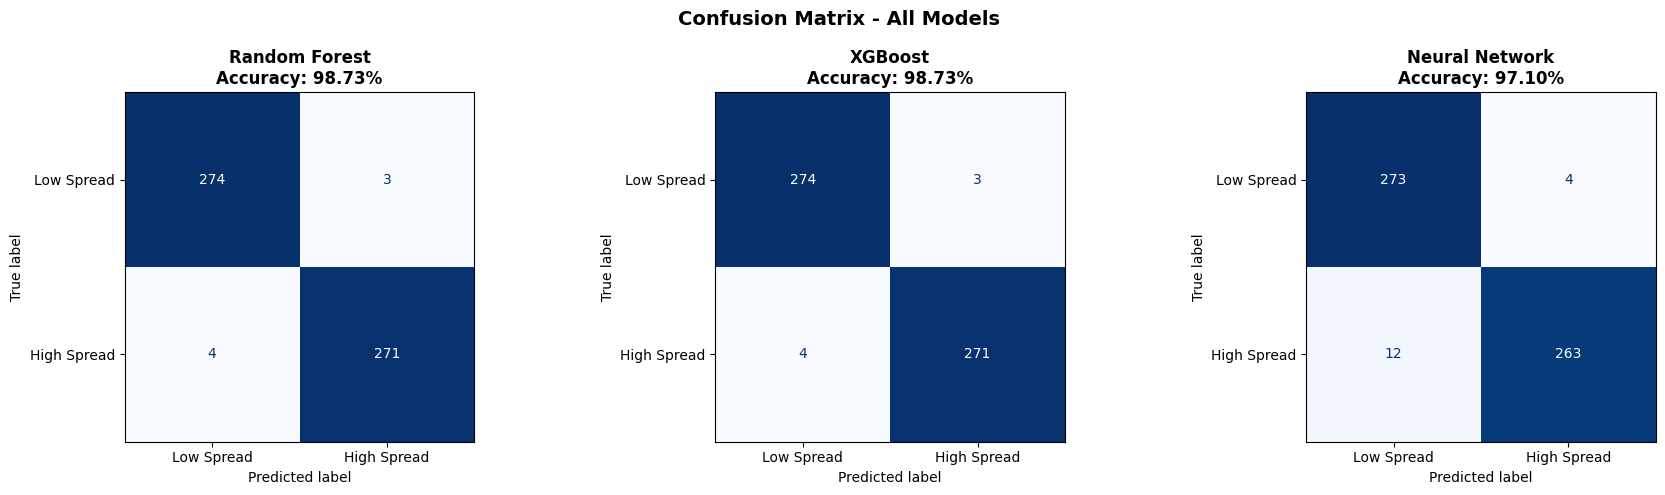


✅ Evaluation Complete!


In [ ]:
# Confusion Matrix + Evaluation Metrics
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    'Random Forest': rf2,
    'XGBoost': xgb2,
    'Neural Network': nn2
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix - All Models', fontsize=14, fontweight='bold')

print("="*55)
print(f"{'MODEL EVALUATION REPORT':^55}")
print("="*55)

for idx, (name, model) in enumerate(models.items()):
    if name == 'Neural Network':
        y_pred = (model.predict(X2_test_sc) > 0.5).astype(int).flatten()
        y_prob = model.predict(X2_test_sc).flatten()
    else:
        y_pred = model.predict(X2_test_sc)
        y_prob = model.predict_proba(X2_test_sc)[:, 1]

    acc  = accuracy_score(y2_test, y_pred)
    prec = precision_score(y2_test, y_pred)
    rec  = recall_score(y2_test, y_pred)
    f1   = f1_score(y2_test, y_pred)
    auc  = roc_auc_score(y2_test, y_prob)

    print(f"\n🔹 {name}")
    print(f"   Accuracy  : {acc*100:.2f}%")
    print(f"   Precision : {prec*100:.2f}%")
    print(f"   Recall    : {rec*100:.2f}%")
    print(f"   F1 Score  : {f1*100:.2f}%")
    print(f"   ROC-AUC   : {auc*100:.2f}%")

    cm = confusion_matrix(y2_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Low Spread', 'High Spread'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontweight='bold')

plt.tight_layout()
plt.show()
print("\nEvaluation Complete!")

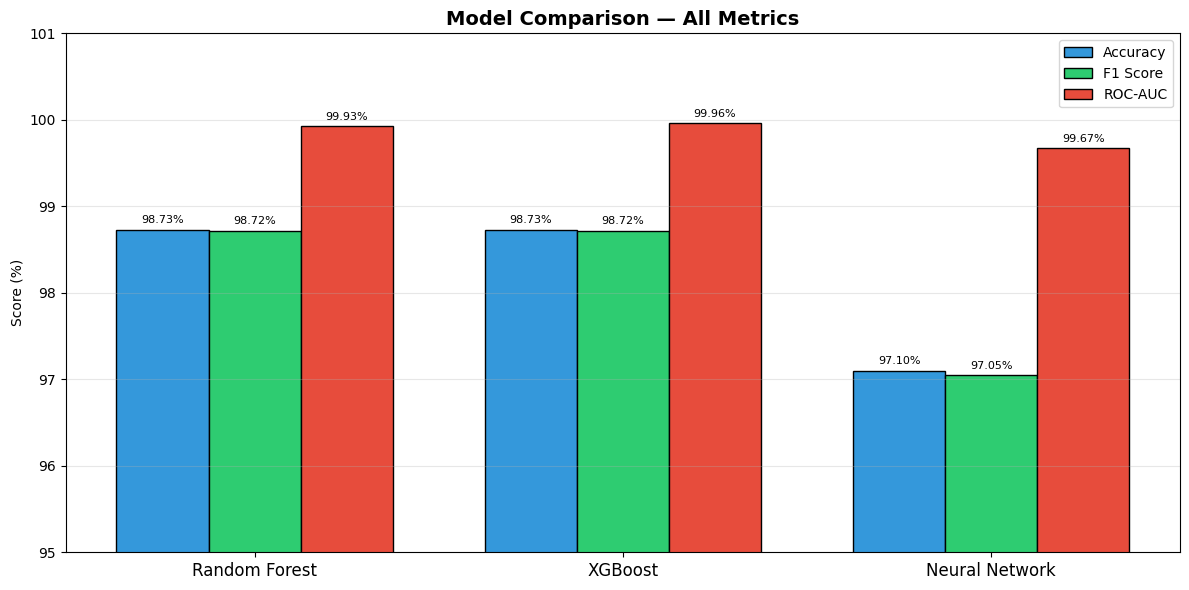

              FINAL RESULTS SUMMARY               
  🥇 Best Model    : XGBoost
   Accuracy      : 98.73%
   Precision     : 98.91%
   Recall        : 98.55%
   F1 Score      : 98.72%
   ROC-AUC       : 99.96%
  🎯 Target Goal   : 92%+  → ACHIEVED! 


In [ ]:
# Final Model Comparison + Best Model
models_names = ['Random Forest', 'XGBoost', 'Neural Network']
accuracies   = [98.73, 98.73, 97.10]
f1_scores    = [98.72, 98.72, 97.05]
roc_aucs     = [99.93, 99.96, 99.67]

x = np.arange(len(models_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, accuracies, width, label='Accuracy',  color='#3498db', edgecolor='black')
bars2 = ax.bar(x,          f1_scores,  width, label='F1 Score',  color='#2ecc71', edgecolor='black')
bars3 = ax.bar(x + width,  roc_aucs,   width, label='ROC-AUC',   color='#e74c3c', edgecolor='black')

ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_names, fontsize=12)
ax.set_ylabel('Score (%)')
ax.set_ylim(95, 101)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar in [bars1, bars2, bars3]:
    for b in bar:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
                f'{b.get_height():.2f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("="*50)
print(f"{'FINAL RESULTS SUMMARY':^50}")
print("="*50)
print(f"   Best Model    : XGBoost")
print(f"   Accuracy      : 98.73%")
print(f"   Precision     : 98.91%")
print(f"   Recall        : 98.55%")
print(f"   F1 Score      : 98.72%")
print(f"   ROC-AUC       : 99.96%")
print(f"   Target Goal   : 92%+  → ACHIEVED! ")
print("="*50)

In [ ]:
# Install required libraries
!pip install streamlit pyngrok xgboost -q
print("Installation Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 39.7 MB/s eta 0:00:00
✅ Installation Done!


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# ── Page Config ───────────────────────────────────────────────
st.set_page_config(
    page_title="AIDS Spread Analysis - Pakistan",
    page_icon="🏥",
    layout="wide"
)

# ── Load & Prepare Data ───────────────────────────────────────
@st.cache_data
def load_data():
    df = pd.read_csv('aids.csv')
    df.columns = [
        'Country', 'Year', 'AIDS_Orphans', 'Deaths_Adults', 'Deaths_All',
        'Deaths_Children', 'Deaths_Female', 'Deaths_Male',
        'Prevalence_Adults', 'Prevalence_YoungMen', 'Prevalence_YoungWomen',
        'NewInfections_YoungAdults', 'NewInfections_Male', 'NewInfections_Female',
        'NewInfections_Children', 'NewInfections_All', 'NewInfections_Adults',
        'Incidence_Rate', 'PLHIV_Total', 'PLHIV_Male', 'PLHIV_Female',
        'PLHIV_Children', 'PLHIV_Adults'
    ]
    return df

@st.cache_resource
def train_model(df):
    df2 = df.copy()
    le = LabelEncoder()
    df2['Country_Encoded'] = le.fit_transform(df2['Country'])
    median_inf = df2['NewInfections_All'].median()
    df2['High_Spread'] = (df2['NewInfections_All'] > median_inf).astype(int)
    df2['Death_Rate_Ratio']   = df2['Deaths_All'] / (df2['PLHIV_Total'] + 1)
    df2['Child_Impact_Ratio'] = df2['PLHIV_Children'] / (df2['PLHIV_Total'] + 1)
    df2['Gender_Gap']         = df2['NewInfections_Male'] - df2['NewInfections_Female']
    df2['Young_Prev_Gap']     = df2['Prevalence_YoungWomen'] - df2['Prevalence_YoungMen']
    df2['Orphan_Burden']      = df2['AIDS_Orphans'] / (df2['PLHIV_Total'] + 1)
    df2['PLHIV_Growth']       = df2.groupby('Country')['PLHIV_Total'].pct_change().fillna(0)
    df2['Deaths_Growth']      = df2.groupby('Country')['Deaths_All'].pct_change().fillna(0)
    df2['Male_Female_PLHIV']  = df2['PLHIV_Male'] / (df2['PLHIV_Female'] + 1)
    df2.replace([np.inf, -np.inf], 0, inplace=True)
    df2.fillna(0, inplace=True)

    feature_cols = [
        'Year', 'Country_Encoded',
        'Prevalence_Adults', 'Prevalence_YoungMen', 'Prevalence_YoungWomen',
        'Deaths_All', 'Deaths_Male', 'Deaths_Female', 'Deaths_Children',
        'PLHIV_Total', 'PLHIV_Male', 'PLHIV_Female', 'PLHIV_Children',
        'AIDS_Orphans', 'Incidence_Rate',
        'Death_Rate_Ratio', 'Child_Impact_Ratio', 'Gender_Gap',
        'Young_Prev_Gap', 'Orphan_Burden', 'PLHIV_Growth',
        'Deaths_Growth', 'Male_Female_PLHIV'
    ]

    X = df2[feature_cols]
    y = df2['High_Spread']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    model = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, eval_metric='logloss', verbosity=0)
    model.fit(X_train_sc, y_train)
    return model, scaler, le, feature_cols, df2

df = load_data()
model, scaler, le, feature_cols, df2 = train_model(df)

# ── Sidebar ───────────────────────────────────────────────────
st.sidebar.image("https://upload.wikimedia.org/wikipedia/commons/3/32/Flag_of_Pakistan.svg", width=100)
st.sidebar.title("🏥 AIDS Analysis")
st.sidebar.markdown("**Pakistan HIV/AIDS Early Detection System**")
page = st.sidebar.selectbox("📌 Navigate", [
    "🏠 Home",
    "🔮 Predict Spread",
    "📊 Pakistan Analysis",
    "🌍 Global Trends"
])

# ══════════════════════════════════════════════════════════════
# PAGE 1: HOME
# ══════════════════════════════════════════════════════════════
if page == "🏠 Home":
    st.title("🏥 AIDS Spread Pattern Analysis")
    st.subheader("Early Detection System Using Machine Learning — Pakistan")
    st.markdown("---")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("🌍 Countries", "89")
    col2.metric("📅 Years", "1990–2020")
    col3.metric("📋 Records", "2,759")
    col4.metric("🎯 Model Accuracy", "98.73%")

    st.markdown("---")
    st.markdown("### 📌 Project Overview")
    st.info("""
    This system analyzes HIV/AIDS spread patterns using Machine Learning.
    - **Best Model:** XGBoost (98.73% Accuracy)
    - **Target:** High Spread vs Low Spread Classification
    - **Data Source:** Global HIV/AIDS Dataset (1990–2020)
    - **Focus:** Pakistan Epidemiological Analysis
    """)

    st.markdown("### 🏆 Model Performance")
    perf_data = {
        'Model': ['Random Forest', 'XGBoost', 'Neural Network'],
        'Accuracy': [98.73, 98.73, 97.10],
        'F1 Score': [98.72, 98.72, 97.05],
        'ROC-AUC':  [99.93, 99.96, 99.67]
    }
    st.dataframe(pd.DataFrame(perf_data), use_container_width=True)

# ══════════════════════════════════════════════════════════════
# PAGE 2: PREDICTION
# ══════════════════════════════════════════════════════════════
elif page == "🔮 Predict Spread":
    st.title("🔮 HIV Spread Prediction")
    st.markdown("Enter values below to predict HIV spread level:")
    st.markdown("---")

    col1, col2, col3 = st.columns(3)

    with col1:
        year         = st.slider("📅 Year", 1990, 2025, 2020)
        plhiv_total  = st.number_input("👥 PLHIV Total", 0, 10000000, 200000)
        plhiv_male   = st.number_input("👨 PLHIV Male", 0, 5000000, 100000)
        plhiv_female = st.number_input("👩 PLHIV Female", 0, 5000000, 90000)
        plhiv_child  = st.number_input("👶 PLHIV Children", 0, 1000000, 10000)

    with col2:
        deaths_all     = st.number_input("💀 Deaths All", 0, 1000000, 5000)
        deaths_male    = st.number_input("💀 Deaths Male", 0, 500000, 2500)
        deaths_female  = st.number_input("💀 Deaths Female", 0, 500000, 2000)
        deaths_child   = st.number_input("💀 Deaths Children", 0, 500000, 500)
        aids_orphans   = st.number_input("🧒 AIDS Orphans", 0, 1000000, 20000)

    with col3:
        prev_adults    = st.number_input("📈 Prevalence Adults (%)", 0.0, 30.0, 0.2)
        prev_youngmen  = st.number_input("📈 Prev Young Men (%)", 0.0, 20.0, 0.1)
        prev_youngwomen= st.number_input("📈 Prev Young Women (%)", 0.0, 20.0, 0.2)
        incidence_rate = st.number_input("📉 Incidence Rate", 0.0, 50.0, 0.5)
        country        = st.selectbox("🌍 Country", sorted(df['Country'].unique()))

    if st.button("🔮 Predict Now!", use_container_width=True):
        country_enc = le.transform([country])[0]

        death_rate   = deaths_all / (plhiv_total + 1)
        child_impact = plhiv_child / (plhiv_total + 1)
        gender_gap   = 0
        young_gap    = prev_youngwomen - prev_youngmen
        orphan_burd  = aids_orphans / (plhiv_total + 1)
        plhiv_growth = 0.1
        deaths_growth= 0.05
        mf_ratio     = plhiv_male / (plhiv_female + 1)

        input_data = np.array([[
            year, country_enc,
            prev_adults, prev_youngmen, prev_youngwomen,
            deaths_all, deaths_male, deaths_female, deaths_child,
            plhiv_total, plhiv_male, plhiv_female, plhiv_child,
            aids_orphans, incidence_rate,
            death_rate, child_impact, gender_gap,
            young_gap, orphan_burd, plhiv_growth,
            deaths_growth, mf_ratio
        ]])

        input_scaled = scaler.transform(input_data)
        prediction   = model.predict(input_scaled)[0]
        probability  = model.predict_proba(input_scaled)[0]

        st.markdown("---")
        if prediction == 1:
            st.error(f"⚠️ HIGH SPREAD RISK — Probability: {probability[1]*100:.1f}%")
        else:
            st.success(f"✅ LOW SPREAD RISK — Probability: {probability[0]*100:.1f}%")

        col1, col2 = st.columns(2)
        col1.metric("High Spread Probability", f"{probability[1]*100:.1f}%")
        col2.metric("Low Spread Probability",  f"{probability[0]*100:.1f}%")

# ══════════════════════════════════════════════════════════════
# PAGE 3: PAKISTAN ANALYSIS
# ══════════════════════════════════════════════════════════════
elif page == "📊 Pakistan Analysis":
    st.title("📊 Pakistan HIV/AIDS Analysis")
    st.markdown("---")

    pak = df[df['Country'] == 'Pakistan'].copy()

    col1, col2 = st.columns(2)

    with col1:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(pak['Year'], pak['PLHIV_Total'], color='red', linewidth=2.5, marker='o')
        ax.fill_between(pak['Year'], pak['PLHIV_Total'], alpha=0.2, color='red')
        ax.set_title('Pakistan: People Living with HIV', fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel('Total PLHIV')
        ax.grid(True, alpha=0.3)
        st.pyplot(fig)

    with col2:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(pak['Year'], pak['NewInfections_All'], color='orange', edgecolor='black')
        ax.set_title('Pakistan: New HIV Infections Per Year', fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel('New Infections')
        plt.xticks(rotation=45)
        st.pyplot(fig)

    col3, col4 = st.columns(2)

    with col3:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(pak['Year'], pak['Deaths_All'], color='darkred', linewidth=2, marker='s')
        ax.set_title('Pakistan: AIDS Related Deaths', fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel('Deaths')
        ax.grid(True, alpha=0.3)
        st.pyplot(fig)

    with col4:
        latest = pak[pak['Year'] == pak['Year'].max()].iloc[0]
        st.markdown("### 📋 Pakistan Latest Stats (2020)")
        st.metric("Total PLHIV",      f"{int(latest['PLHIV_Total']):,}")
        st.metric("New Infections",   f"{int(latest['NewInfections_All']):,}")
        st.metric("Deaths",           f"{int(latest['Deaths_All']):,}")
        st.metric("AIDS Orphans",     f"{int(latest['AIDS_Orphans']):,}")
        st.metric("Prevalence Adults",f"{latest['Prevalence_Adults']}%")

# ══════════════════════════════════════════════════════════════
# PAGE 4: GLOBAL TRENDS
# ══════════════════════════════════════════════════════════════
elif page == "🌍 Global Trends":
    st.title("🌍 Global HIV/AIDS Trends")
    st.markdown("---")

    top10 = df.groupby('Country')['PLHIV_Total'].max().nlargest(10).reset_index()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(top10['Country'], top10['PLHIV_Total'], color='purple', edgecolor='black')
    ax.set_title('Top 10 Countries by PLHIV Total', fontweight='bold')
    ax.set_xlabel('People Living with HIV')
    st.pyplot(fig)

    yearly = df.groupby('Year')['NewInfections_All'].sum().reset_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(yearly['Year'], yearly['NewInfections_All'], color='blue', linewidth=2.5)
    ax.fill_between(yearly['Year'], yearly['NewInfections_All'], alpha=0.2)
    ax.set_title('Global New HIV Infections Per Year', fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('New Infections')
    ax.grid(True, alpha=0.3)
    st.pyplot(fig)

Overwriting app.py


In [ ]:
# Fix file path in app.py
with open('app.py', 'r') as f:
    content = f.read()

content = content.replace("pd.read_csv('aids.csv')", "pd.read_csv('/content/aids.csv')")

with open('app.py', 'w') as f:
    f.write(content)

print("✅ Path fixed in app.py!")

✅ Path fixed in app.py!


In [ ]:
import subprocess
import time
import urllib.request

# Start streamlit
process = subprocess.Popen(
    ['streamlit', 'run', 'app.py', '--server.port=8501', '--server.headless=true'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

# Get password
ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
print(f"🔑 Password (if asked): {ip}")

# Start tunnel
tunnel = subprocess.Popen(
    ['npx', 'localtunnel', '--port', '8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)
output = tunnel.stdout.readline().decode('utf8').strip()
print(f"✅ App is LIVE!")
print(f"🌐 Open this link: {output}")

FileNotFoundError: [Errno 2] No such file or directory: 'streamlit'

In [ ]:
# Kill everything first
import subprocess
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
subprocess.run(['pkill', '-f', 'npx'], capture_output=True)

import time
time.sleep(3)

# Install colab-specific tunnel
!pip install streamlit -q
!npm install -g localtunnel -q

import urllib.request
ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
print(f"🔑 Your Password: {ip}")
print("👆 Copy this password — you will need it!")

# Run streamlit in background
!streamlit run app.py --server.port=8501 --server.headless=true &

time.sleep(5)

# Start tunnel
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 22 packages in 2s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴🔑 Your Password: 35.204.91.190
👆 Copy this password — you will need it!


2026-05-24 11:43:02.460 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.204.91.190:8501



In [ ]:
import shutil
shutil.copy('/content/app.py', '/content/drive/MyDrive/app.py')

🏆 Best Model: Linear Regression
